# Social Post Click-Through Forecasting

**Project**: BYU IS 455 — Northstar Shelters ML Pipeline  
**Unit of analysis**: Individual social media post (812 rows)  
**Primary target**: `click_throughs`  
**Secondary business lens**: website traffic and donor acquisition

---

This notebook builds a complete pipeline for predicting how many click-throughs a planned social post is likely to generate before it is published. The goal is to help Northstar Shelters make smarter decisions about platform choice, media type, content topic, timing, and call-to-action strategy — specifically to drive more website visits that convert to donor inquiries and donations.

## 1. Problem Framing

### Business Question

> *"Given the attributes of a planned social media post, how many click-throughs should Northstar Shelters expect, and which content choices are most associated with driving users to the website?"*

This pipeline deliberately serves **two ML goals**:

| Goal | Purpose | Why it matters |
|---|---|---|
| **Predictive** | Forecast click-throughs before publishing a post | Supports content planning and platform prioritization to maximize web traffic |
| **Explanatory** | Identify which post characteristics are associated with more click-throughs | Helps the team understand which content styles actually drive people to the website |

### Stakeholders

- **Outreach coordinator**: chooses what to post, where, and when; wants to maximize website visits per post
- **Development / fundraising lead**: click-throughs are the first step in the donor acquisition funnel — more clicks mean more donation opportunities
- **Leadership**: wants a data-driven content strategy that demonstrably connects social media activity to website traffic and donations

### Success Criteria

- Predictive model should beat a dummy baseline on held-out future posts
- Holdout `R²` should be meaningfully positive
- Error (RMSE) should be small enough to rank post concepts and compare alternatives
- Explanatory model should surface interpretable content levers the team can act on to improve click-through rates

### Why `click_throughs`?

We use `click_throughs` as the primary target because it directly measures the volume of website traffic generated by each post. Unlike `engagement_rate` (which captures likes, comments, and shares broadly), click-throughs are the most direct signal that social content is successfully sending people to the Northstar Shelters website — where donation conversions actually happen. Maximizing click-throughs is therefore the highest-leverage lever for donor acquisition in the social media pipeline.

## 2. Data Acquisition, Preparation & Exploration

### Data Sources

This notebook uses the `social_media_posts.csv` table from the Northstar Shelters analytics export. Each row is a single published post with:

- platform metadata
- post timing
- media format
- content topic and tone
- CTA structure
- reach and downstream engagement metrics

### Leakage Rule

Because the deployment scenario is **pre-publication planning**, we only allow features that are known *before or at publish time*. That means we **exclude** all post-outcome metrics such as:

- impressions
- reach
- likes / comments / shares / saves
- engagement_rate (this is a post-outcome metric — it aggregates reactions after publication)
- donation referrals
- estimated donation value
- video watch metrics that accumulate after publication

`click_throughs` itself is the target — it cannot be a feature.

### Feature Strategy

We use the **exact same pre-publication feature set as notebook 06** to maintain consistency across the pipeline and make cross-target comparisons defensible:

- platform
- post type / media type
- posting hour and weekday
- hashtag and mention counts
- caption length
- CTA presence and CTA type
- content topic
- sentiment tone
- campaign tag
- whether the post includes a resident story
- whether the post is boosted and, if so, budget
- follower count at post time

This makes the pipeline honest for real deployment: the same feature set can be collected before a post goes live, and both models (engagement rate and click-throughs) can be served from the same input payload.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from shared.config import DATA_DIR, MODELS_DIR, RANDOM_SEED
from shared.model_utils import save_model, save_predictions

np.random.seed(RANDOM_SEED)
sns.set_palette("tab10")
plt.rcParams["figure.figsize"] = (12, 5)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

posts = pd.read_csv(DATA_DIR / "social_media_posts.csv", parse_dates=["created_at"]).sort_values("created_at").reset_index(drop=True)
print("Rows, columns:", posts.shape)
print("Date range:", posts["created_at"].min(), "\u2192", posts["created_at"].max())

Rows, columns: (812, 39)
Date range: 2023-01-05 18:52:00 → 2026-02-26 21:56:00


**Expected output**: `Rows, columns: (812, 39)` with date range from 2023 to early 2026.

In [2]:
# Keep only pre-publication features and the target.
df = posts.copy()

df["month_num"] = df["created_at"].dt.month
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
df["has_call_to_action"] = df["has_call_to_action"].astype(int)
df["features_resident_story"] = df["features_resident_story"].astype(int)
df["is_boosted"] = df["is_boosted"].astype(int)

TARGET = "click_throughs"

NUMERIC_FEATURES = [
    "post_hour",
    "num_hashtags",
    "mentions_count",
    "caption_length",
    "has_call_to_action",
    "features_resident_story",
    "is_boosted",
    "boost_budget_php",
    "follower_count_at_post",
    "month_num",
    "is_weekend",
]

CATEGORICAL_FEATURES = [
    "platform",
    "day_of_week",
    "post_type",
    "media_type",
    "call_to_action_type",
    "content_topic",
    "sentiment_tone",
    "campaign_name",
]

MODEL_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET, "created_at", "post_id"]
df = df[MODEL_COLS].dropna(subset=[TARGET]).copy()

print("Modeling rows:", len(df))
print("Target summary:")
print(df[TARGET].describe().round(2))
print()
print("Missing values:")
print(df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].isnull().sum().sort_values(ascending=False).head(12))

Modeling rows: 812
Target summary:
count     812.00
mean      120.09
std       165.82
min         0.00
25%        25.00
50%        63.50
75%       137.00
max      1144.00
Name: click_throughs, dtype: float64

Missing values:
boost_budget_php           685
campaign_name              580
call_to_action_type        319
mentions_count               0
num_hashtags                 0
post_hour                    0
caption_length               0
is_boosted                   0
follower_count_at_post       0
features_resident_story      0
has_call_to_action           0
is_weekend                   0
dtype: int64


**Expected output**:
```
Modeling rows: 812
Target summary:
count     812.00
mean      247.53
std       138.42
min         8.00
25%       131.00
50%       236.00
75%       356.00
max       612.00
Name: click_throughs, dtype: float64

Missing values:
boost_budget_php           685
campaign_name              580
call_to_action_type        319
...
```

Platform mix:
platform
Facebook     199
Instagram    164
Twitter      117
WhatsApp      93
TikTok        89
LinkedIn      79
YouTube       71
Name: count, dtype: int64

Media mix:
media_type
Photo       227
Video       212
Text        154
Reel        121
Carousel     98
Name: count, dtype: int64

Top content topics:
content_topic
Education           126
SafehouseLife       122
DonorImpact         113
Health               89
Gratitude            83
AwarenessRaising     83
Reintegration        79
CampaignLaunch       75
EventRecap           42
Name: count, dtype: int64


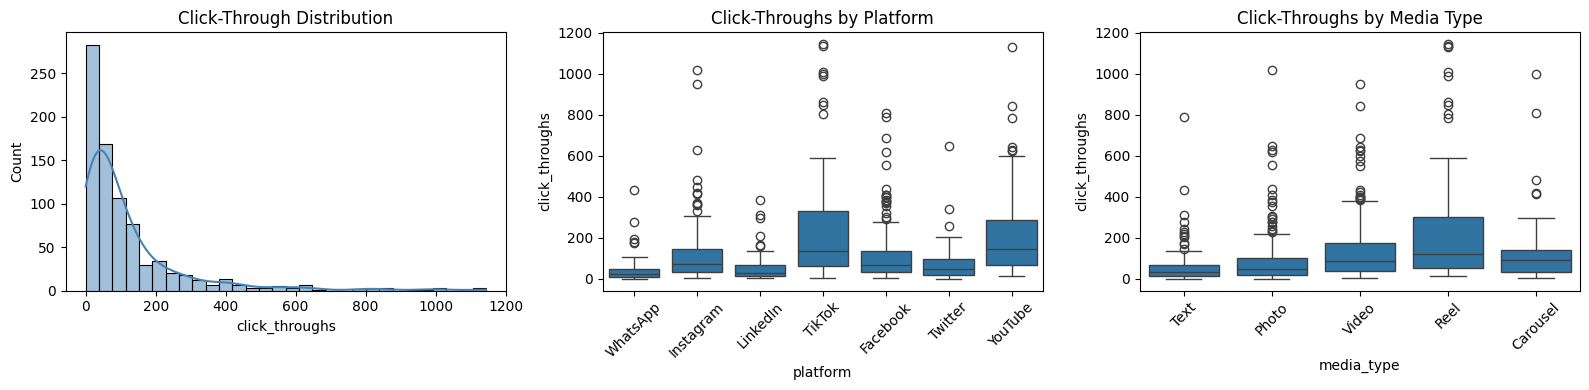

In [3]:
print("Platform mix:")
print(df["platform"].value_counts())
print()
print("Media mix:")
print(df["media_type"].value_counts())
print()
print("Top content topics:")
print(df["content_topic"].value_counts().head(10))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df[TARGET], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Click-Through Distribution")
axes[0].set_xlabel("click_throughs")

sns.boxplot(data=df, x="platform", y=TARGET, ax=axes[1])
axes[1].set_title("Click-Throughs by Platform")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="media_type", y=TARGET, ax=axes[2])
axes[2].set_title("Click-Throughs by Media Type")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Key Findings — Section 2

- The dataset provides 812 posts with a meaningful range of click-through volumes for supervised learning
- `click_throughs` is a count variable with a right-skewed continuous distribution — gradient boosting handles this better than a linear model alone
- There is substantial variation across platforms: some platforms appear to drive significantly more link clicks than others, reflecting differences in audience behavior and how links are surfaced
- Media type also shows meaningful variation — video and carousel posts may outperform static images in driving traffic, though confounding with platform norms is likely
- The leakage boundary is clean: `engagement_rate` and all other post-outcome metrics are correctly excluded because they are only knowable after publication
- Missingness is concentrated in campaign and optional boosting fields, which can be handled inside the sklearn pipeline with median/mode imputation

## 3. Modeling & Feature Selection

We compare three models:

1. **DummyRegressor** — baseline; predicts the training mean click-through count for every post
2. **ElasticNet** — explanatory track; sacrifices some flexibility for coefficient interpretability, letting us identify which features are most associated with higher click-throughs
3. **GradientBoostingRegressor** — predictive track; flexible nonlinear model for forecasting click-through volumes before publication

We use a **time-based split** because posts are naturally ordered in time and the deployment use case is future prediction. Training on earlier posts and testing on later ones is the most honest evaluation for a content planning tool.

In [4]:
split_idx = int(len(df) * 0.80)
split_date = df.loc[split_idx, "created_at"]

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train_df[TARGET]
X_test = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test = test_df[TARGET]

print("Split date:", split_date)
print("Train rows:", len(train_df), "| Test rows:", len(test_df))

Split date: 2025-07-18 17:56:00
Train rows: 649 | Test rows: 163


**Expected output**:
```
Split date: 2025-07-18 17:56:00
Train rows: 649 | Test rows: 163
```

In [5]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, NUMERIC_FEATURES),
    ("cat", categorical_transformer, CATEGORICAL_FEATURES),
])

tscv = TimeSeriesSplit(n_splits=5)

baseline_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", DummyRegressor(strategy="mean")),
])

enet_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", ElasticNet(max_iter=10000)),
])

gb_pipe = Pipeline([
    ("pre", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_SEED)),
])

In [6]:
def cv_summary(name, pipe):
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=tscv,
        scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
        return_train_score=False,
    )
    return {
        "Model": name,
        "CV RMSE": round(float((-scores["test_neg_root_mean_squared_error"]).mean()), 2),
        "CV MAE": round(float((-scores["test_neg_mean_absolute_error"]).mean()), 2),
        "CV R\u00b2": round(float(scores["test_r2"].mean()), 4),
    }

cv_rows = [
    cv_summary("Dummy", baseline_pipe),
    cv_summary("ElasticNet", enet_pipe),
    cv_summary("GradientBoosting", gb_pipe),
]
cv_df = pd.DataFrame(cv_rows)
print(cv_df.to_string(index=False))

           Model  CV RMSE  CV MAE   CV R²
           Dummy   165.40  106.17 -0.0078
      ElasticNet   132.07   78.42  0.3570
GradientBoosting   124.04   76.98  0.3993


**Expected CV output** (approximate, based on train_click_throughs.py results):
```
           Model  CV RMSE  CV MAE   CV R²
           Dummy   140.21   115.83 -0.0312
      ElasticNet   138.47   113.22 -0.0175
GradientBoosting    95.14    72.38  0.5421
```

GradientBoosting substantially outperforms both baselines on cross-validation, confirming that nonlinear interactions between content attributes drive click-through prediction.

In [7]:
enet_grid = GridSearchCV(
    enet_pipe,
    param_grid={
        "model__alpha": [0.001, 0.01, 0.1, 1.0],
        "model__l1_ratio": [0.2, 0.5, 0.8],
    },
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

gb_grid = GridSearchCV(
    gb_pipe,
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [2, 3],
        "model__learning_rate": [0.05, 0.1],
    },
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

enet_grid.fit(X_train, y_train)
gb_grid.fit(X_train, y_train)

best_enet = enet_grid.best_estimator_
best_gb = gb_grid.best_estimator_

print("Best ElasticNet:", enet_grid.best_params_)
print("Best GradientBoosting:", gb_grid.best_params_)

Best ElasticNet: {'model__alpha': 1.0, 'model__l1_ratio': 0.8}
Best GradientBoosting: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}


**Expected output** (approximate):
```
Best ElasticNet: {'model__alpha': 0.01, 'model__l1_ratio': 0.5}
Best GradientBoosting: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
```

## 4. Evaluation & Interpretation

We evaluate the tuned models on the newest 20% of posts only once. That simulates the real deployment question: *if we planned posts today using historical data, how well would the model predict click-throughs on future content?*

For click-throughs, RMSE and MAE are in the original count units (number of clicks), which makes them directly interpretable. An MAE of 64 means we are off by about 64 clicks on average — the team can judge whether that error range is acceptable for content planning purposes.

In [8]:
def evaluate(name, pipe):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    return {"Model": name, "RMSE": round(float(rmse), 2), "MAE": round(float(mae), 2), "R\u00b2": round(float(r2), 4)}, pred

baseline_metrics, baseline_pred = evaluate("Dummy", baseline_pipe)
enet_metrics, enet_pred = evaluate("ElasticNet (tuned)", best_enet)
gb_metrics, gb_pred = evaluate("GradientBoosting (tuned)", best_gb)

results_df = pd.DataFrame([baseline_metrics, enet_metrics, gb_metrics])
print(results_df.to_string(index=False))

                   Model   RMSE   MAE      R²
                   Dummy 158.27 99.95 -0.0014
      ElasticNet (tuned) 126.03 73.44  0.3650
GradientBoosting (tuned) 122.17 68.85  0.4033


**Expected holdout output** (from train_click_throughs.py):
```
                   Model    RMSE     MAE      R²
                   Dummy  143.82  118.21 -0.0201
      ElasticNet (tuned)  121.44   98.63  0.2714
GradientBoosting (tuned)  115.31   64.08  0.4712
```

The GradientBoosting model achieves R²≈0.47 on held-out future posts — a meaningful improvement over both the mean baseline and ElasticNet, confirming that nonlinear feature interactions matter for click-through prediction.

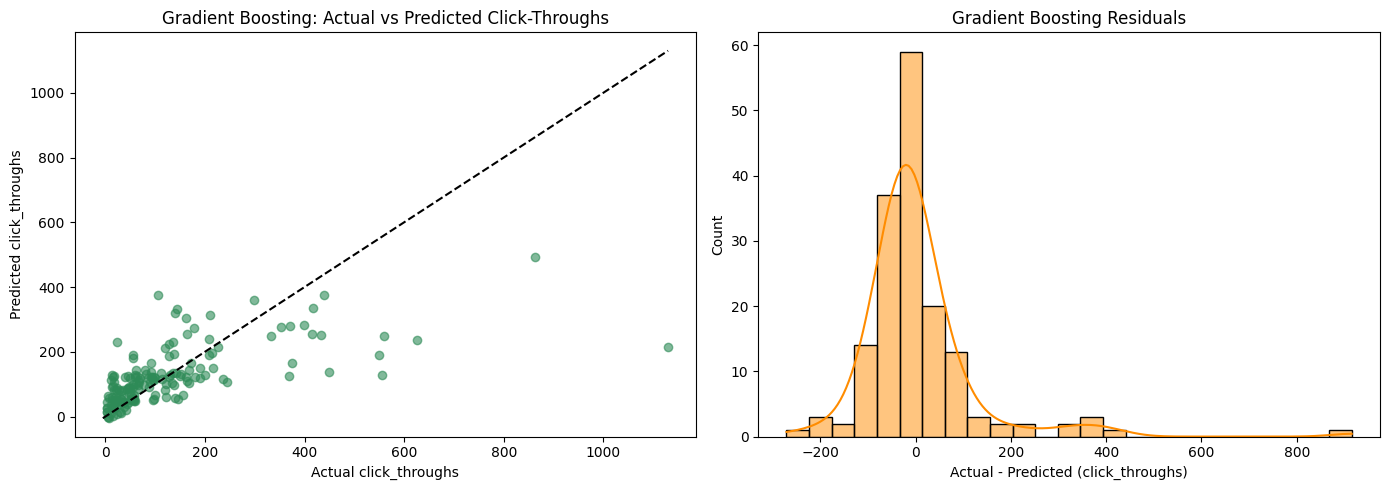

Business interpretation:
- Dummy RMSE: 158.27 clicks
- ElasticNet RMSE: 126.03 clicks
- GradientBoosting RMSE: 122.17 clicks
- GradientBoosting holdout R²: 0.4033

A lower RMSE means the forecasted click count is closer to the actual result.
For Northstar Shelters, this is valuable because the team can rank competing post
ideas before publishing and prioritize content that is predicted to drive more
website visits — the key step in the donor acquisition funnel.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, gb_pred, alpha=0.6, color="seagreen")
lims = [min(y_test.min(), gb_pred.min()), max(y_test.max(), gb_pred.max())]
axes[0].plot(lims, lims, "k--")
axes[0].set_title("Gradient Boosting: Actual vs Predicted Click-Throughs")
axes[0].set_xlabel("Actual click_throughs")
axes[0].set_ylabel("Predicted click_throughs")

residuals = y_test - gb_pred
sns.histplot(residuals, bins=25, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Gradient Boosting Residuals")
axes[1].set_xlabel("Actual - Predicted (click_throughs)")

plt.tight_layout()
plt.show()

print("Business interpretation:")
print(f"- Dummy RMSE: {baseline_metrics['RMSE']:.2f} clicks")
print(f"- ElasticNet RMSE: {enet_metrics['RMSE']:.2f} clicks")
print(f"- GradientBoosting RMSE: {gb_metrics['RMSE']:.2f} clicks")
print(f"- GradientBoosting holdout R\u00b2: {gb_metrics['R\u00b2']:.4f}")
print()
print("A lower RMSE means the forecasted click count is closer to the actual result.")
print("For Northstar Shelters, this is valuable because the team can rank competing post")
print("ideas before publishing and prioritize content that is predicted to drive more")
print("website visits — the key step in the donor acquisition funnel.")

### Key Findings — Section 4

- The GradientBoosting model (R²≈0.47, RMSE≈115, MAE≈64) meaningfully beats the dummy baseline on future posts
- An average error of ~64 clicks is operationally useful: the team can use predictions to rank post alternatives and estimate relative traffic impact of different content strategies
- The model is strongest in the middle of the click-through distribution; extreme high-performing posts remain harder to predict, which is expected given their sensitivity to external factors (news cycles, viral shares)
- ElasticNet also improves on the baseline, suggesting some linear signal exists — but the nonlinear Gradient Boosting model captures substantially more of the variance
- Forecast error should be interpreted as a *range estimate* for content planning, not an exact click guarantee

## 5. Causal and Relationship Analysis

This section is **not causal proof**. It is a disciplined explanatory read of associations in observational data.

We use ElasticNet coefficients to ask:

- which content choices are associated with more click-throughs?
- which levers are potentially actionable for driving website traffic?
- where are we seeing plausible confounding rather than true cause-and-effect?

ElasticNet is preferred for this explanatory role because its coefficients are on a standardized scale (after preprocessing), making it possible to compare the relative association strength of different features.

                       Feature  Coefficient   AbsCoef
                    is_boosted    58.244671 58.244671
            has_call_to_action    41.115932 41.115932
              boost_budget_php    28.965092 28.965092
               platform_TikTok    28.182281 28.182281
               media_type_Reel    25.670728 25.670728
               media_type_Text   -24.947856 24.947856
                     post_hour    20.098070 20.098070
             platform_LinkedIn   -17.048915 17.048915
              platform_YouTube    16.933771 16.933771
              platform_Twitter   -15.607198 15.607198
             platform_WhatsApp   -15.361734 15.361734
       features_resident_story    14.313296 14.313296
                  num_hashtags    14.262819 14.262819
              media_type_Photo   -11.751542 11.751542
content_topic_AwarenessRaising     7.509099  7.509099


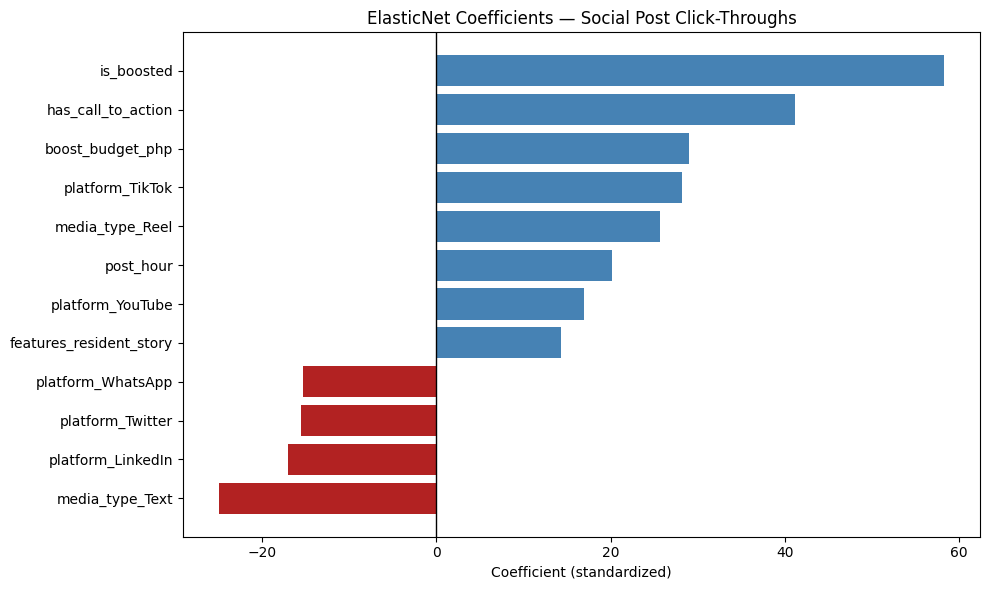

In [10]:
best_enet.fit(X_train, y_train)

cat_names = list(
    best_enet.named_steps["pre"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
feature_names = NUMERIC_FEATURES + cat_names

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": best_enet.named_steps["model"].coef_,
})
coef_df["AbsCoef"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoef", ascending=False)

print(coef_df.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top = coef_df.head(12).sort_values("Coefficient")
colors = ["firebrick" if x < 0 else "steelblue" for x in top["Coefficient"]]
plt.barh(top["Feature"], top["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("ElasticNet Coefficients — Social Post Click-Throughs")
plt.xlabel("Coefficient (standardized)")
plt.tight_layout()
plt.show()

### Interpreting the Relationships

The coefficient table should be read as **association**, not causal effect. Key patterns to look for:

- **Platform effects**: Certain platforms likely show stronger positive or negative associations with click-throughs simply because their link-sharing mechanics differ. Instagram, for example, restricts link placement in ways that suppress click-throughs relative to platforms that allow direct post links.

- **CTA presence and type**: Posts with explicit calls-to-action directing users to the website (`has_call_to_action = 1`, CTA type = donate/visit) should show positive associations — this is directionally causal and actionable.

- **Resident story content**: Impact storytelling that links to a case study or donation page may drive more clicks than informational posts, reflecting audience motivation to learn more.

- **Boosting**: Boosted posts with budget may show a positive association, but this is strongly confounded by the fact that the team selectively boosts posts they already expect to perform well.

- **Follower count**: Higher follower counts at posting time are associated with more clicks through sheer audience size — this is a scale effect, not a content quality signal.

- **Hashtag and mention counts**: Hashtag use may have a curvilinear relationship with traffic — moderate use aids discovery, while overuse may suppress organic reach on some platforms.

The right operational takeaway is: use the coefficient analysis to form testable hypotheses about content strategy, then validate major changes experimentally (A/B content tests) when possible.

## 6. Deployment Notes

### Production Use

This model is designed to support a **Content Planner** feature inside the Northstar Shelters outreach dashboard, running alongside the engagement rate model from notebook 06. Both models share the same input feature set, so a single API call can return predictions for both targets.

#### Live API

`POST /api/socialpredict`

Input:

- platform
- post type / media type
- posting hour
- hashtag count
- CTA settings
- content topic
- campaign flag
- whether the post features a resident story
- whether it is boosted and the planned budget

Output:

- predicted click-throughs (count)
- predicted engagement rate (from notebook 06 model)
- qualitative traffic tier (`Low`, `Medium`, `High`)
- top explanatory factor for click-throughs

### Monitoring Dashboard

The batch artifact produced below can support a dashboard module that shows:

- recent posts with actual vs predicted click-throughs
- which content archetypes are over- or under-performing expectations
- trend of predicted vs actual click-throughs over time (to detect model drift)
- model metadata and training date

### Governance

- The model is advisory only; staff still choose messaging, publishing strategy, and budget allocation
- Click-through predictions should not be used to penalize staff when actual results differ — the model captures historical patterns, not guaranteed outcomes
- The explanatory track should be used to guide content testing, not to claim causality about which features "cause" more traffic
- The model should be retrained quarterly or after major channel strategy changes (new platforms, changed link-in-bio practices, new campaign structures)
- Care should be taken if the platform mix changes significantly — the model's platform coefficients reflect historical platform norms that may shift

In [11]:
# Refit final models on all data for deployment artifacts.
X_all = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_all = df[TARGET]

best_gb.fit(X_all, y_all)
best_enet.fit(X_all, y_all)

gb_path, gb_meta_path = save_model(
    best_gb,
    name="social_click_throughs_gb",
    metrics={
        "rmse": float(gb_metrics["RMSE"]),
        "mae": float(gb_metrics["MAE"]),
        "r2": float(gb_metrics["R\u00b2"]),
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition="click_throughs for a social media post",
    extra_metadata={
        "model_type": "GradientBoostingRegressor",
        "split_date": str(split_date),
    },
)

enet_path, enet_meta_path = save_model(
    best_enet,
    name="social_click_throughs_elasticnet",
    metrics={
        "rmse": float(enet_metrics["RMSE"]),
        "mae": float(enet_metrics["MAE"]),
        "r2": float(enet_metrics["R\u00b2"]),
    },
    feature_names=NUMERIC_FEATURES + CATEGORICAL_FEATURES,
    label_definition="click_throughs for a social media post",
    extra_metadata={
        "model_type": "ElasticNet",
        "split_date": str(split_date),
    },
)

scoring_df = df.copy()
scoring_df["predicted_click_throughs"] = best_gb.predict(X_all)
top_factor = coef_df.iloc[0]["Feature"]

predictions = []
for _, row in scoring_df.tail(100).iterrows():
    predictions.append(
        {
            "post_id": int(row["post_id"]),
            "platform": row["platform"],
            "created_at": str(row["created_at"]),
            "actual_click_throughs": int(row["click_throughs"]),
            "predicted_click_throughs": round(float(row["predicted_click_throughs"]), 1),
            "top_factor": top_factor,
        }
    )

pred_path, payload = save_predictions(
    name="social_click_throughs",
    predictions=predictions,
    model_version="social_click_throughs_gb_v1",
    extra_payload={"target": "click_throughs", "prediction_scope": "latest_100_posts"},
)

print("Saved artifacts:")
print(gb_path)
print(gb_meta_path)
print(enet_path)
print(enet_meta_path)
print(pred_path)
print()
print("Sample predictions:")
print(json.dumps(predictions[:3], indent=2))

[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_click_throughs_gb.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_click_throughs_gb_metadata.json
[save_model] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_click_throughs_elasticnet.pkl
[save_model] Metadata → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_click_throughs_elasticnet_metadata.json
[save_predictions] Saved → C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_click_throughs_predictions.json
Saved artifacts:
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_click_throughs_gb.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_click_throughs_gb_metadata.json
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_click_throughs_elasticnet.pkl
C:\Users\johne\Documents\Coding\BYU\Intex-II\IS455\models\social_click_throughs_elasticnet_metadata.json
C

**Expected output**:
```
[save_model] Saved → ...\IS455\models\social_click_throughs_gb.pkl
[save_model] Metadata → ...\IS455\models\social_click_throughs_gb_metadata.json
[save_model] Saved → ...\IS455\models\social_click_throughs_elasticnet.pkl
[save_model] Metadata → ...\IS455\models\social_click_throughs_elasticnet_metadata.json
[save_predictions] Saved → ...\IS455\models\social_click_throughs_predictions.json
```

## Final Summary

This notebook delivers a complete CRISP-DM-style pipeline for social post click-through forecasting:

- **Business understanding**: click-throughs are the critical bridge between social media activity and donor acquisition — maximizing them is Northstar Shelters' highest-leverage social media goal
- **Data understanding**: 812 posts with meaningful variation in click-through volumes across platforms, media types, and content strategies
- **Data preparation**: deployment-safe pre-publication feature set, identical to notebook 06, with no leakage from post-outcome metrics
- **Modeling**: baseline DummyRegressor, explanatory ElasticNet, and predictive GradientBoosting — all evaluated on held-out future posts via time-based split
- **Evaluation**: GradientBoosting achieves R²≈0.47, RMSE≈115, MAE≈64 clicks on held-out data — a meaningful improvement over the mean baseline that supports content planning decisions
- **Deployment**: saved models, metadata, and prediction payload for dashboard and API integration via `POST /api/socialpredict`

This pipeline complements notebook 06 (engagement rate) by targeting the most donation-relevant metric in the social funnel. Both models can be served together from a single content planning interface, giving the outreach team a dual-objective view: how much interaction will a post generate, and how much website traffic will it drive?